<a href="https://colab.research.google.com/github/apurvakumbhar/Deep_Learning/blob/main/DLExperiment_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.metrics import accuracy_score

In [ ]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print(X.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9473684210526315


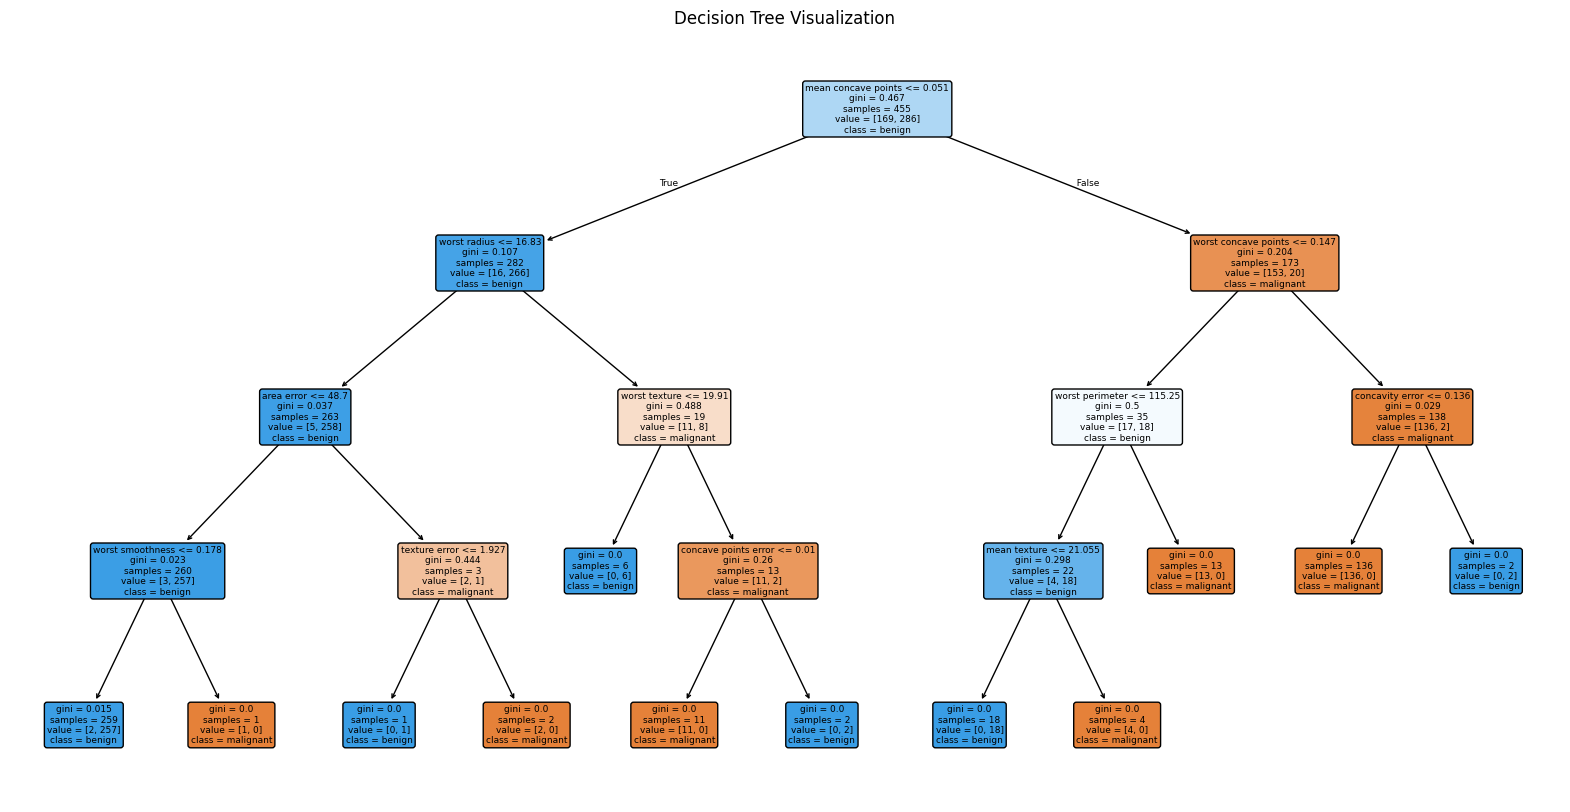

In [ ]:
plt.figure(figsize=(20,10))
plot_tree(
    dt,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True,
    rounded=True
)
plt.title("Decision Tree Visualization")
plt.show()

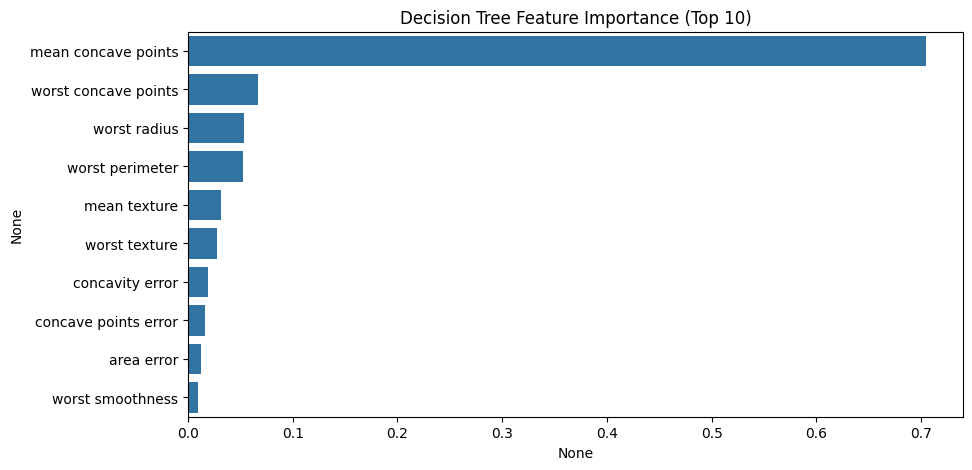

In [ ]:
imp = pd.Series(dt.feature_importances_, index=data.feature_names)
imp = imp.sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=imp[:10], y=imp[:10].index)
plt.title("Decision Tree Feature Importance (Top 10)")
plt.show()

In [ ]:
rf = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.9649122807017544


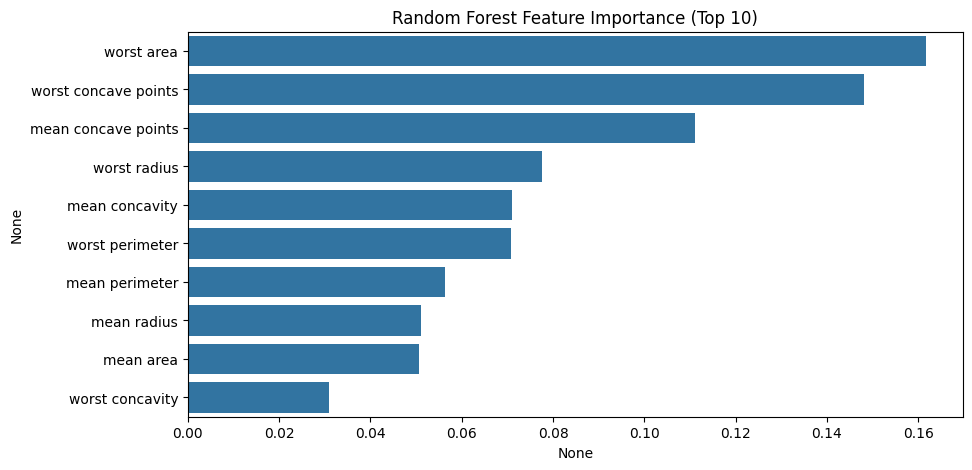

In [ ]:
imp_rf = pd.Series(rf.feature_importances_, index=data.feature_names)
imp_rf = imp_rf.sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=imp_rf[:10], y=imp_rf[:10].index)
plt.title("Random Forest Feature Importance (Top 10)")
plt.show()

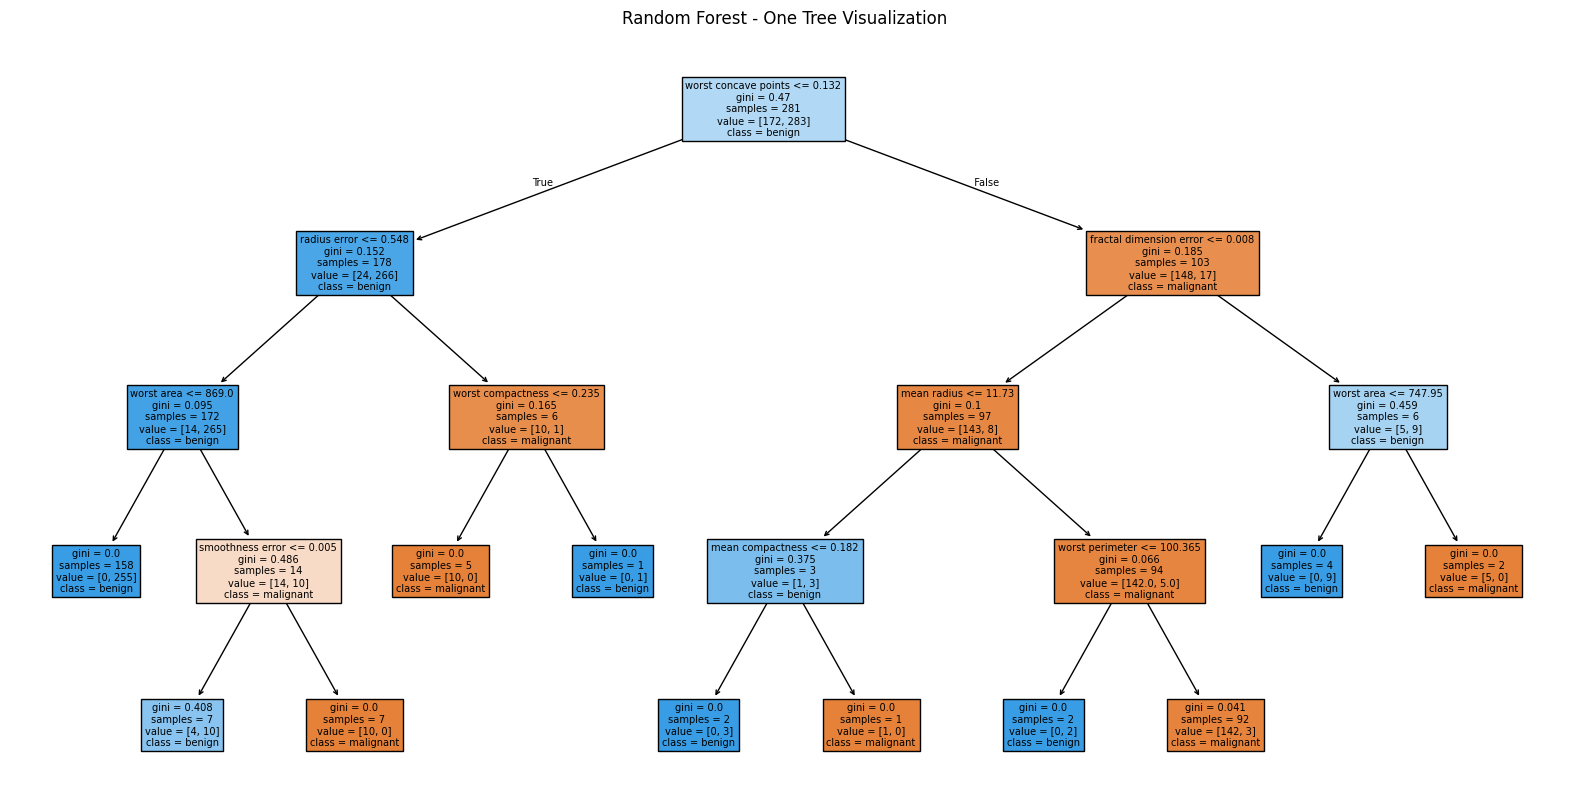

In [ ]:
plt.figure(figsize=(20,10))
plot_tree(
    rf.estimators_[0],
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True
)
plt.title("Random Forest - One Tree Visualization")
plt.show()

In [ ]:
iso = IsolationForest(contamination=0.1, random_state=42)
iso.fit(X_scaled)

y_pred_iso = iso.predict(X_scaled)   # IMPORTANT: use full dataset

In [ ]:
anomaly = y_pred_iso == -1
normal = y_pred_iso == 1

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

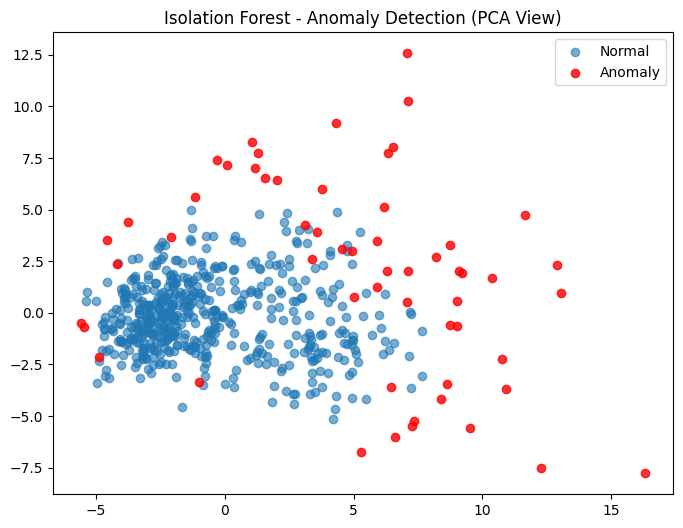

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(X_pca[normal, 0], X_pca[normal, 1],
            label="Normal", alpha=0.6)

plt.scatter(X_pca[anomaly, 0], X_pca[anomaly, 1],
            label="Anomaly", color='red', alpha=0.8)

plt.title("Isolation Forest - Anomaly Detection (PCA View)")
plt.legend()
plt.show()

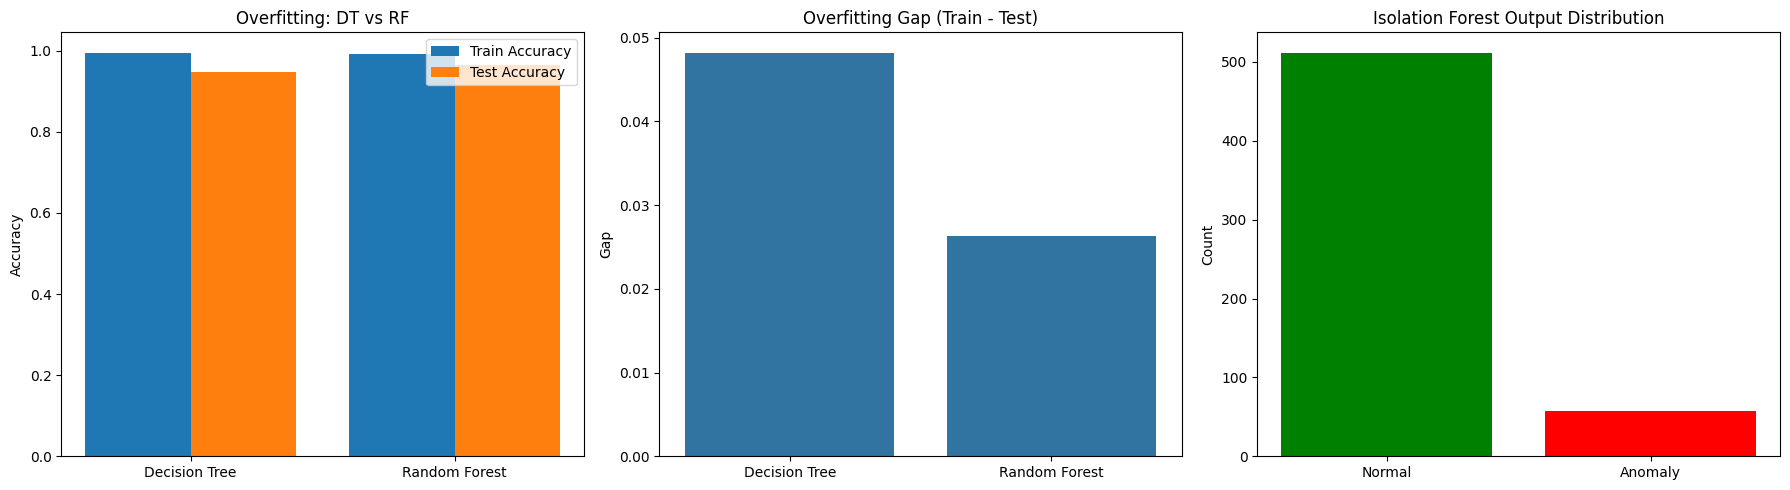

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. Accuracy for DT & RF
# -----------------------------
dt_train_acc = dt.score(X_train, y_train)
dt_test_acc = dt.score(X_test, y_test)

rf_train_acc = rf.score(X_train, y_train)
rf_test_acc = rf.score(X_test, y_test)

models = ["Decision Tree", "Random Forest"]

train_acc = [dt_train_acc, rf_train_acc]
test_acc = [dt_test_acc, rf_test_acc]

# -----------------------------
# 2. Isolation Forest output
# -----------------------------
iso_labels = iso.predict(X_scaled)
normal_count = np.sum(iso_labels == 1)
anomaly_count = np.sum(iso_labels == -1)

# -----------------------------
# 3. Combined Plot
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# 📌 (A) Overfitting comparison
x = np.arange(len(models))

axes[0].bar(x - 0.2, train_acc, 0.4, label="Train Accuracy")
axes[0].bar(x + 0.2, test_acc, 0.4, label="Test Accuracy")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_title("Overfitting: DT vs RF")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# 📌 (B) Overfitting gap
gap = [
    dt_train_acc - dt_test_acc,
    rf_train_acc - rf_test_acc
]

sns.barplot(x=models, y=gap, ax=axes[1])
axes[1].set_title("Overfitting Gap (Train - Test)")
axes[1].set_ylabel("Gap")

# 📌 (C) Isolation Forest distribution
axes[2].bar(["Normal", "Anomaly"], [normal_count, anomaly_count], color=["green", "red"])
axes[2].set_title("Isolation Forest Output Distribution")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()